Forecast future sales for a retail store using past sales data. This project teaches time series modeling and forecasting.


# 1. Import Libraries

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# 2. Load Dataset

In [38]:
df = pd.read_csv('/content/SampleSuperstore.csv')

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


# 3. Check Columns

In [39]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

# 4. Create Date Column

In [40]:
dates = pd.date_range(start='2020-01-01', periods=len(df))

df['Date'] = dates

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Date
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,2020-01-01
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,2020-01-02
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,2020-01-03
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,2020-01-04
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,2020-01-05


# 5. Select Required Columns

In [41]:
df = df[['Date', 'Sales']]

df.head()

,Date,Sales
0,2020-01-01,261.9600
1,2020-01-02,731.9400
2,2020-01-03,14.6200
3,2020-01-04,957.5775
4,2020-01-05,22.3680


# 6. Rename Columns

In [42]:
df.columns = ['Date', 'Sales']

df.head()

,Date,Sales
0,2020-01-01,261.9600
1,2020-01-02,731.9400
2,2020-01-03,14.6200
3,2020-01-04,957.5775
4,2020-01-05,22.3680


# 7. Convert Date Format

In [43]:
df['Date'] = pd.to_datetime(df['Date'])

df.head()

,Date,Sales
0,2020-01-01,261.9600
1,2020-01-02,731.9400
2,2020-01-03,14.6200
3,2020-01-04,957.5775
4,2020-01-05,22.3680


# 8. Set Date as Index

In [44]:
df.set_index('Date', inplace=True)

df.head()

,Sales
Date,
2020-01-01,261.9600
2020-01-02,731.9400
2020-01-03,14.6200
2020-01-04,957.5775
2020-01-05,22.3680


# 9. Visualize Sales Data

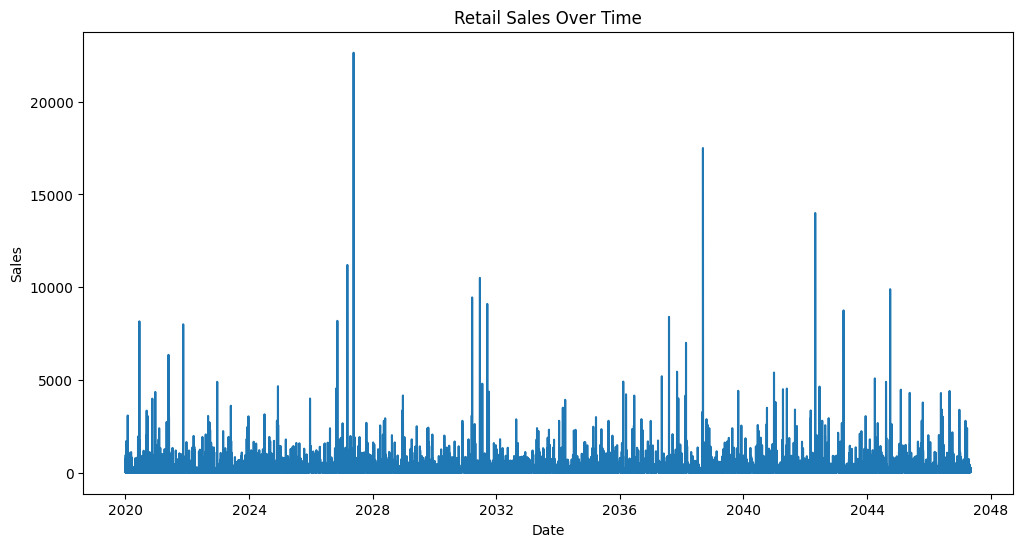

In [45]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df['Sales'])

plt.title('Retail Sales Over Time')

plt.xlabel('Date')

plt.ylabel('Sales')

plt.show()

# 10. Time Series Decomposition

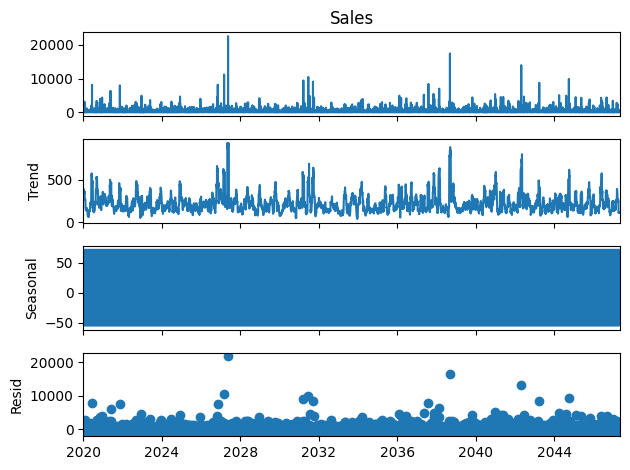

In [46]:
decomposition = seasonal_decompose(df['Sales'], model='additive', period=30)

decomposition.plot()

plt.show()

# 11. Train Test Split

In [47]:
train = df.iloc[:800]

test = df.iloc[800:]

print(train.shape)

print(test.shape)

(800, 1)
(9194, 1)


# 12. ARIMA Model

In [48]:
model = ARIMA(train['Sales'], order=(5,1,0))

model_fit = model.fit()

predictions = model_fit.forecast(steps=len(test))

# 13. ARIMA Predictions

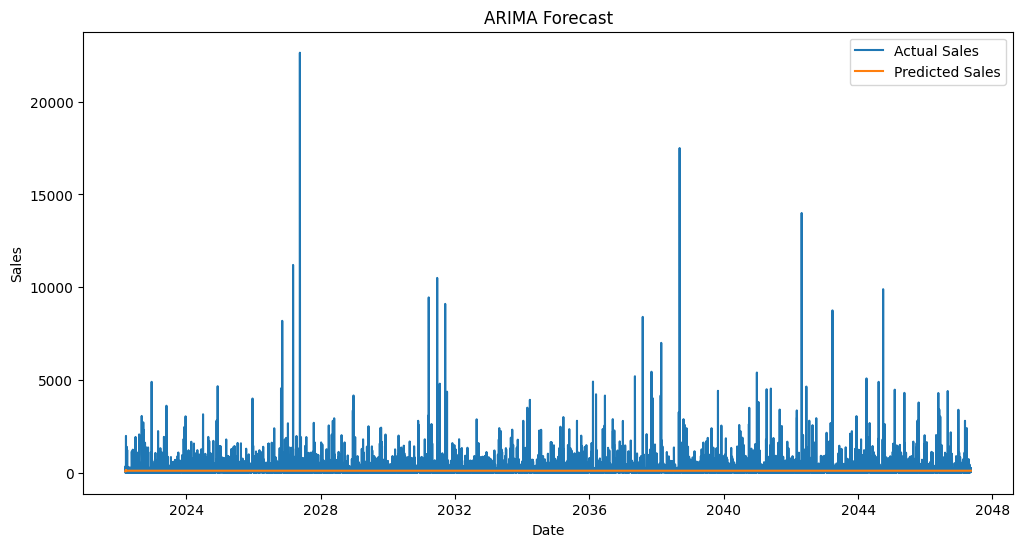

In [49]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test['Sales'], label='Actual Sales')

plt.plot(test.index, predictions, label='Predicted Sales')

plt.legend()

plt.title('ARIMA Forecast')

plt.xlabel('Date')

plt.ylabel('Sales')

plt.show()

# 14. Model Evaluation

In [50]:
mae = mean_absolute_error(test['Sales'], predictions)

rmse = np.sqrt(mean_squared_error(test['Sales'], predictions))

print("MAE:", mae)

print("RMSE:", rmse)

MAE: 216.3834956515307
RMSE: 634.1939013707639


# 15. Forecast Future Sales

In [51]:
future_forecast = model_fit.forecast(steps=30)

print(future_forecast)

2022-03-11     79.007628
2022-03-12     92.151247
2022-03-13    109.447835
2022-03-14     91.317384
2022-03-15     99.406279
2022-03-16    140.396041
2022-03-17    100.624706
2022-03-18    105.661037
2022-03-19    108.312783
2022-03-20    105.809148
2022-03-21    108.150362
2022-03-22    114.262786
2022-03-23    106.734655
2022-03-24    108.165046
2022-03-25    108.568519
2022-03-26    108.266700
2022-03-27    108.790471
2022-03-28    109.646228
2022-03-29    108.255628
2022-03-30    108.613973
2022-03-31    108.673717
2022-04-01    108.646009
2022-04-02    108.748203
2022-04-03    108.857074
2022-04-04    108.606466
2022-04-05    108.689955
2022-04-06    108.698165
2022-04-07    108.697554
2022-04-08    108.715538
2022-04-09    108.727147
Freq: D, Name: predicted_mean, dtype: float64


# 16. Future Forecast Plot

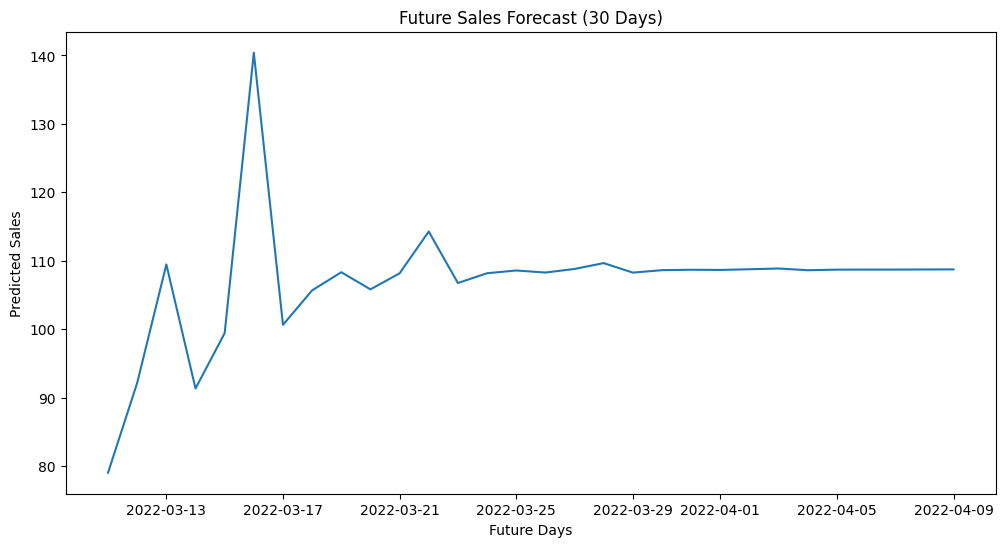

In [52]:
plt.figure(figsize=(12,6))

plt.plot(future_forecast)

plt.title('Future Sales Forecast (30 Days)')

plt.xlabel('Future Days')

plt.ylabel('Predicted Sales')

plt.show()

# 18. Prophet Model

In [53]:
!pip install prophet

In [54]:
from prophet import Prophet

In [55]:
prophet_df = df.reset_index()

prophet_df.columns = ['ds', 'y']

prophet_df.head()

,ds,y
0,2020-01-01,261.9600
1,2020-01-02,731.9400
2,2020-01-03,14.6200
3,2020-01-04,957.5775
4,2020-01-05,22.3680


In [56]:
prophet_model = Prophet()

prophet_model.fit(prophet_df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [57]:
future = prophet_model.make_future_dataframe(periods=30)

forecast = prophet_model.predict(future)

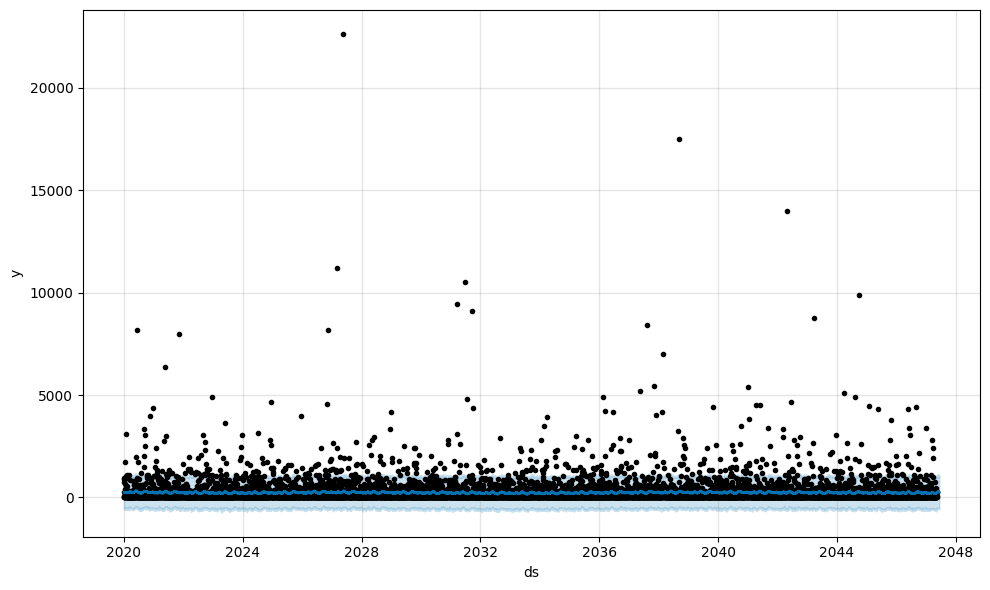

In [58]:
prophet_model.plot(forecast)

plt.show()

# 19. Install TensorFlow

In [59]:
!pip install tensorflow

# 20. Import LSTM Libraries

In [60]:
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense, LSTM

# 21. Scale Data

In [61]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(df[['Sales']])

scaled_data

array([[0.01155206],
       [0.0323127 ],
       [0.0006262 ],
       ...,
       [0.01140258],
       [0.00128792],
       [0.0107216 ]])

# 22. Create Training Data

In [62]:
x_train = []
y_train = []

for i in range(60, len(scaled_data)):
    x_train.append(scaled_data[i-60:i, 0])
    y_train.append(scaled_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

print(x_train.shape)

(9934, 60, 1)


# 23. Build LSTM Model

In [63]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=True,
               input_shape=(x_train.shape[1], 1)))

model.add(LSTM(units=50))

model.add(Dense(1))

# 24. Compile Model

In [64]:
model.compile(optimizer='adam', loss='mean_squared_error')

# 25. Train LSTM Model

In [65]:
model.fit(x_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
311/311 ━━━━━━━━━━━━━━━━━━━━ 28s 68ms/step - loss: 7.6909e-04
Epoch 2/5
311/311 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - loss: 7.6332e-04
Epoch 3/5
311/311 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - loss: 7.6320e-04
Epoch 4/5
311/311 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - loss: 7.6243e-04
Epoch 5/5
311/311 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - loss: 7.6545e-04


# 26. LSTM Predictions

In [66]:
predictions = model.predict(x_train)

predictions = scaler.inverse_transform(predictions)

311/311 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step


# 27. Plot LSTM Predictions

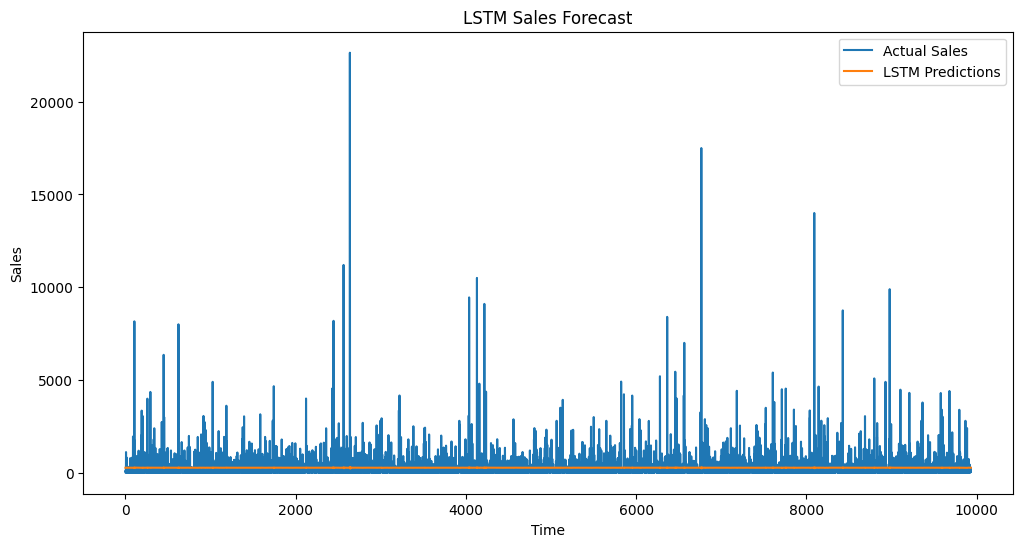

In [67]:
plt.figure(figsize=(12,6))

plt.plot(df['Sales'].values[60:], label='Actual Sales')

plt.plot(predictions, label='LSTM Predictions')

plt.title('LSTM Sales Forecast')

plt.xlabel('Time')

plt.ylabel('Sales')

plt.legend()

plt.show()

#28.Conclusion

In this project, retail sales forecasting was performed using historical sales data. Time series analysis techniques were applied to visualize and decompose the data into trend and seasonal components. ARIMA, Prophet, and LSTM models were implemented for forecasting future sales. The models were validated using test data and evaluated using forecasting metrics. The project demonstrates how machine learning and deep learning techniques can help retail businesses improve sales prediction and decision-making.